<h1 style="text-align:center ">Gold Price Predictions</h1> 

 ## Project Data [   source](https://www.kaggle.com/datasets/altruistdelhite04/gold-price-data)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn import metrics

## Loading the data 

In [3]:
gold_data=pd.read_csv('data/gld_price_data.csv')

## exploring the dataset


In [4]:
gold_data.shape

(2290, 6)

In [5]:
gold_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   str    
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), str(1)
memory usage: 107.5 KB


## have Missing values or nulls?

In [6]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

## projecting  parts of the data **first & last 5 rows respectively**

In [7]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


## statistical measurement of the data  

In [8]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


## converting the date into a separate year month day columns , and dropin the old date      

In [9]:
gold_data['Date'] = pd.to_datetime(gold_data['Date'], format='%m/%d/%Y')
gold_data['Year'] = gold_data['Date'].dt.year
gold_data['Month'] = gold_data['Date'].dt.month
gold_data['DayOfWeek'] = gold_data['Date'].dt.dayofweek
gold_data = gold_data.drop(columns=['Date'])


In [10]:
gold_data.head()

,SPX,GLD,USO,SLV,EUR/USD,Year,Month,DayOfWeek
0,1447.160034,84.860001,78.470001,15.180,1.471692,2008,1,2
1,1447.160034,85.570000,78.370003,15.285,1.474491,2008,1,3
2,1411.630005,85.129997,77.309998,15.167,1.475492,2008,1,4
3,1416.180054,84.769997,75.500000,15.053,1.468299,2008,1,0
4,1390.189941,86.779999,76.059998,15.590,1.557099,2008,1,1


## contracting the corelation between feather

In [11]:
corelation = gold_data.corr()


## visualizing the corelation via a heatmap 

<Axes: >

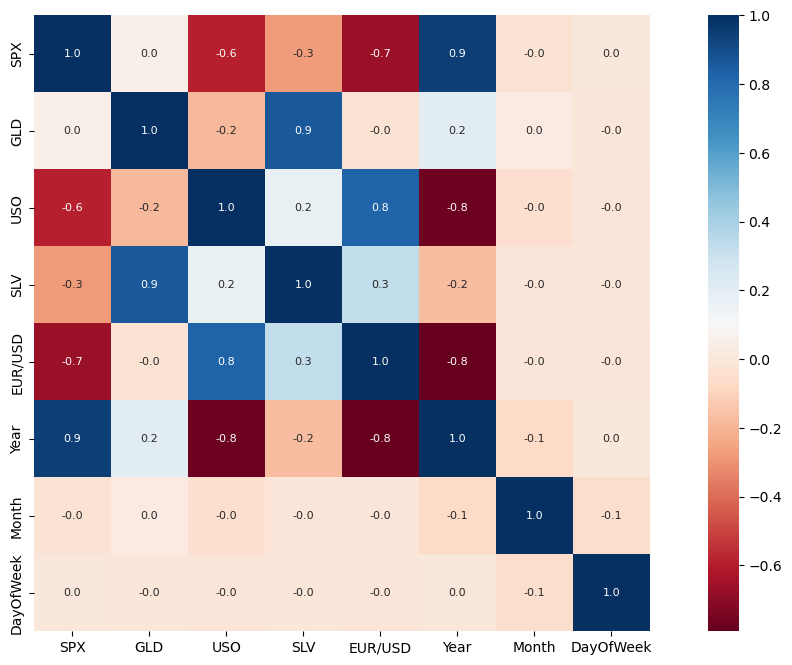

In [12]:
# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (15,8))
sns.heatmap(corelation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap="RdBu")

### corelation of the gold values

In [13]:
corelation['GLD']

SPX          0.049345
GLD          1.000000
USO         -0.186360
SLV          0.866632
EUR/USD     -0.024375
Year         0.206654
Month        0.020494
DayOfWeek   -0.001227
Name: GLD, dtype: float64

### checking the distribution of the gld            

<Axes: xlabel='GLD', ylabel='Count'>

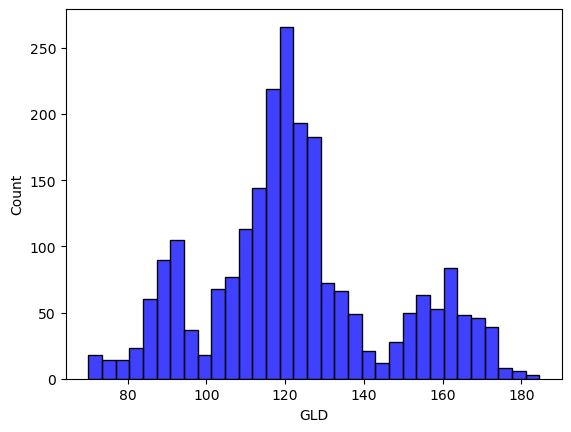

In [14]:
sns.histplot(gold_data['GLD'],color="blue")

### Checking for duplicates

In [15]:
gold_data.duplicated().sum()

np.int64(0)

### Outlier detection using Boxplots

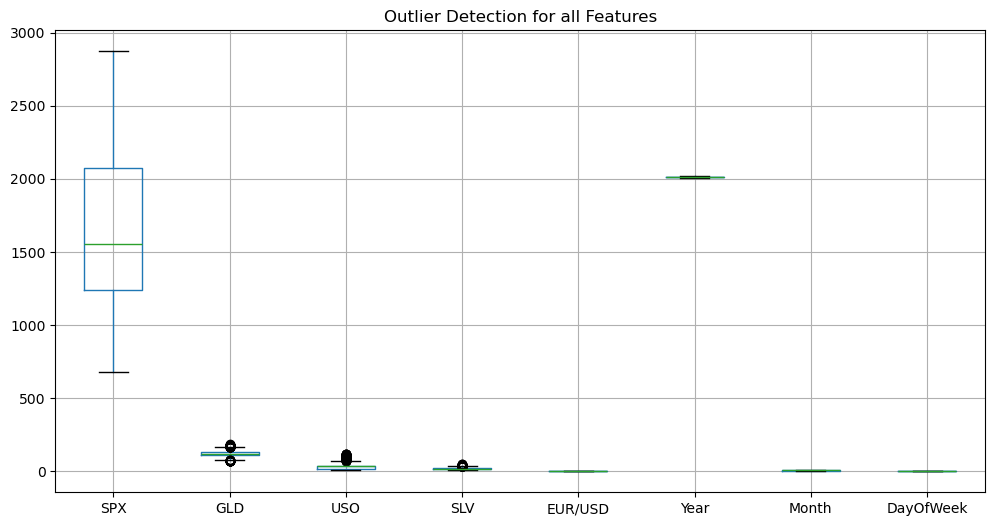

In [16]:
plt.figure(figsize=(12, 6))
gold_data.boxplot()
plt.title('Outlier Detection for all Features')
plt.show()

### Visualizing the strong relationship between Silver and Gold

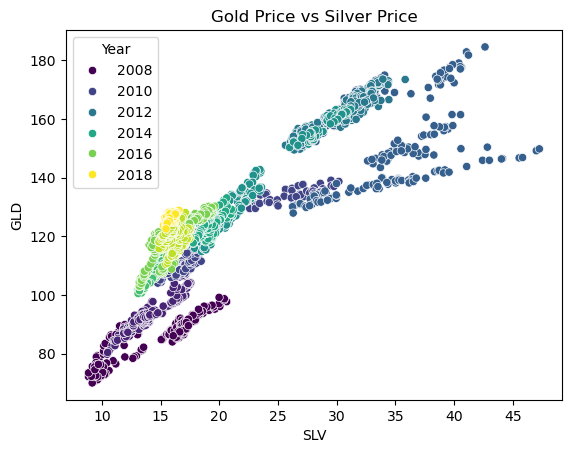

In [17]:
sns.scatterplot(x='SLV', y='GLD', data=gold_data, hue='Year', palette='viridis')
plt.title('Gold Price vs Silver Price')
plt.show()

### Gold price trend over the years

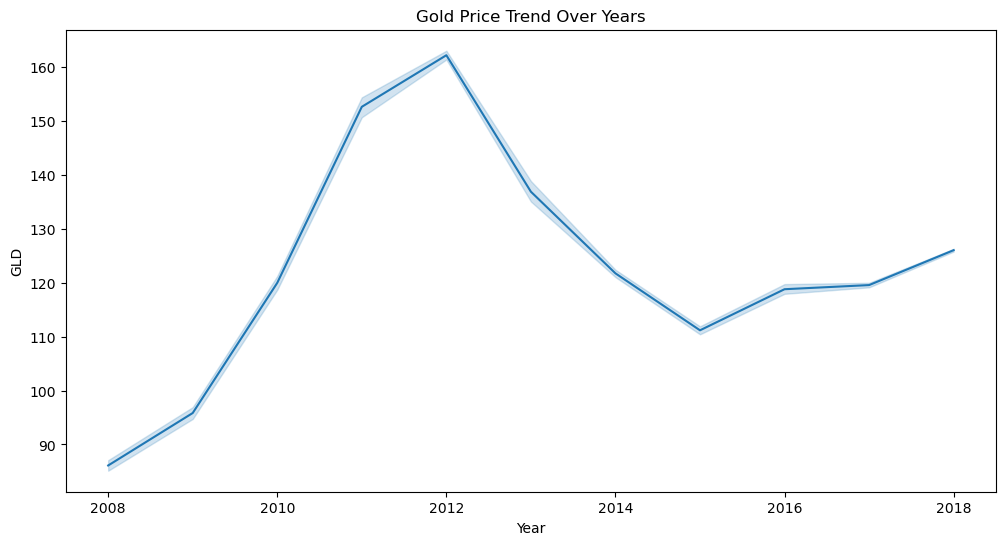

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='GLD', data=gold_data)
plt.title('Gold Price Trend Over Years')
plt.show()

### selver price trend over the years

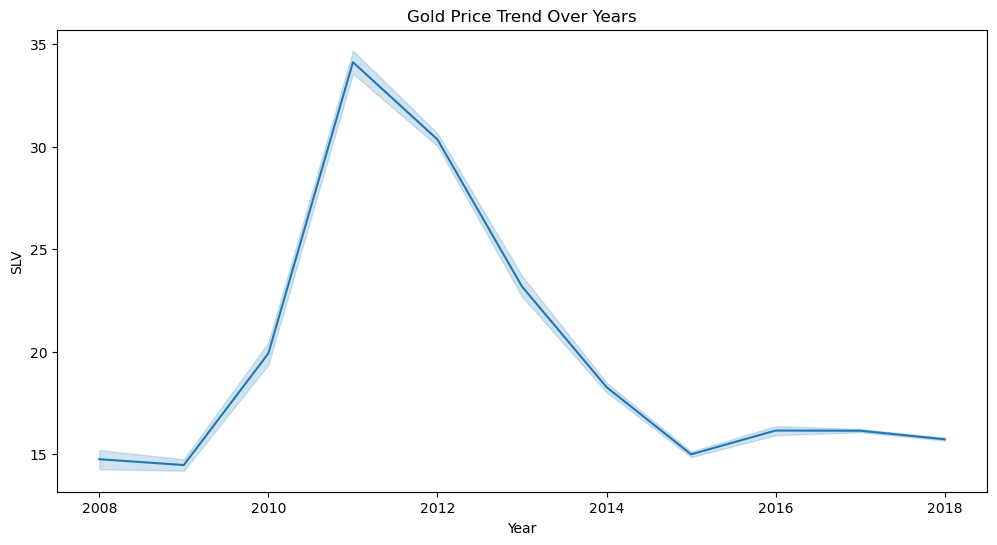

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='SLV', data=gold_data)
plt.title('Gold Price Trend Over Years')
plt.show()

## preparing the data for the model and  removing 
### We will use   todays data to predict tomorrow's gold price  & drop the un important data month dayofweek 

In [20]:
# Create a new column that pulls tomorrow's Gold price into today's row
gold_data['Target_Next_Day_GLD'] = gold_data['GLD'].shift(-1)

# dorp last row 
gold_data = gold_data.dropna() 

# prepare the target and the training data 
y = gold_data['Target_Next_Day_GLD']
X = gold_data.drop(columns=['GLD', 'Target_Next_Day_GLD', 'Month','DayOfWeek'])

## Spliting the data to test and train

In [21]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=2)

## Train the models

In [22]:
rand1ome_forest=RandomForestRegressor(n_estimators=100)
rand1ome_forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Model training and  prediction 

In [23]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=2),
    "Gradient Boosting": GradientBoostingRegressor(random_state=2)
}
# 2. Initialize the results dictionary
results = {
    "Model": [],
    "R2 Score": [],
    "RMSE": [],
    "MAE": []
}
print(f"\n{'Model Name':<20} | {'R² Score':<10} | {'RMSE':<10} | {'MAE':<10}")
print("-" * 60)

# 3. Train and evaluate loop
for name, model in models.items():
    # Train and predict
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    
    # Calculate metrics
    r2 = metrics.r2_score(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse=np.sqrt(mse)
    mae = metrics.mean_absolute_error(y_test, predictions)
    
    # Store results
    results["Model"].append(name)
    results["R2 Score"].append(r2)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    
    # Print formatted output to console
    print(f"{name:<20} | {r2:<10.4f} | {rmse:<10.2f} | {mae:<10.2f}")



Model Name           | R² Score   | RMSE       | MAE       
------------------------------------------------------------
Linear Regression    | 0.8922     | 7.58       | 5.32      
Random Forest        | 0.9882     | 2.51       | 1.62      
Gradient Boosting    | 0.9829     | 3.02       | 2.03      


In [24]:
# pred=rand1ome_forest.predict(x_test)
# x = np.ravel(y_test) 
# y = np.ravel(pred)
# plt.figure(figsize=(8, 8))
# sns.regplot(x=x, y=y, 
#             scatter_kws={'alpha': 0.5, 'color': 'royalblue'}, 
#             line_kws={'color': 'red', 'linewidth': 2})

# plt.title("True Forecasting: Actual vs Predicted")
# # plt.show()

## see the model performance  

<Axes: title={'center': 'True Liner regression: Actual vs Predicted'}>

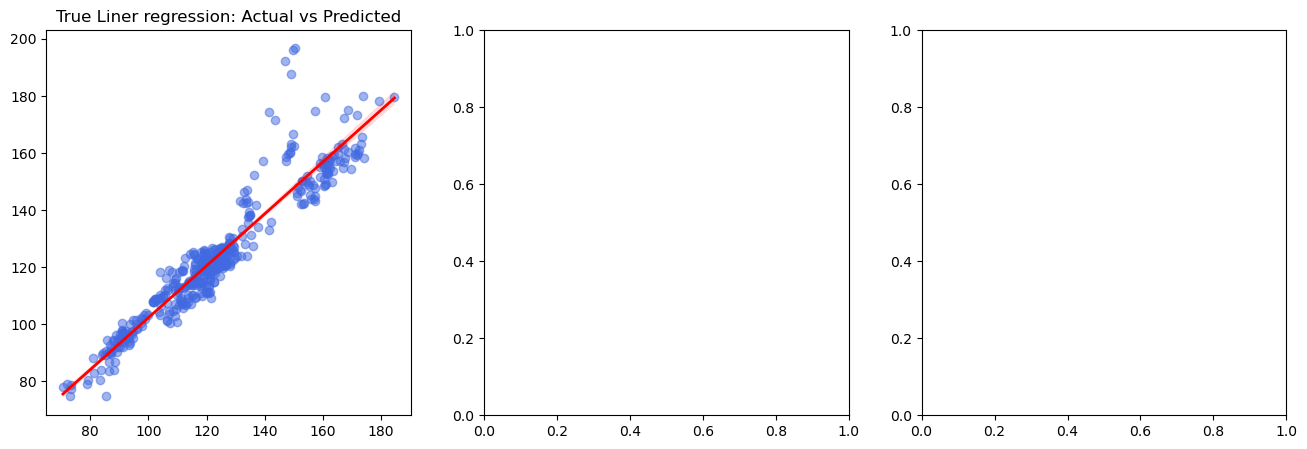

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5)) 
x=np.ravel(y_test)
# linear regression
lr=np.ravel(models["Linear Regression"].predict(x_test))

axes[0].set_title("True Liner regression: Actual vs Predicted")
sns.regplot(x=x, y=lr, ax=axes[0],
            scatter_kws={'alpha': 0.5, 'color': 'royalblue'}, 
            line_kws={'color': 'red', 'linewidth': 2})


### converting the result into a dataname for visualization        

In [26]:
results_df=pd.DataFrame(results)
results_df

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.892210,7.582262,5.324779
1,Random Forest,0.988203,2.508408,1.617456
2,Gradient Boosting,0.982884,3.021420,2.029957


### 4. Visualize the comparison

/tmp/ipykernel_363279/1171768049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="Blues_d")


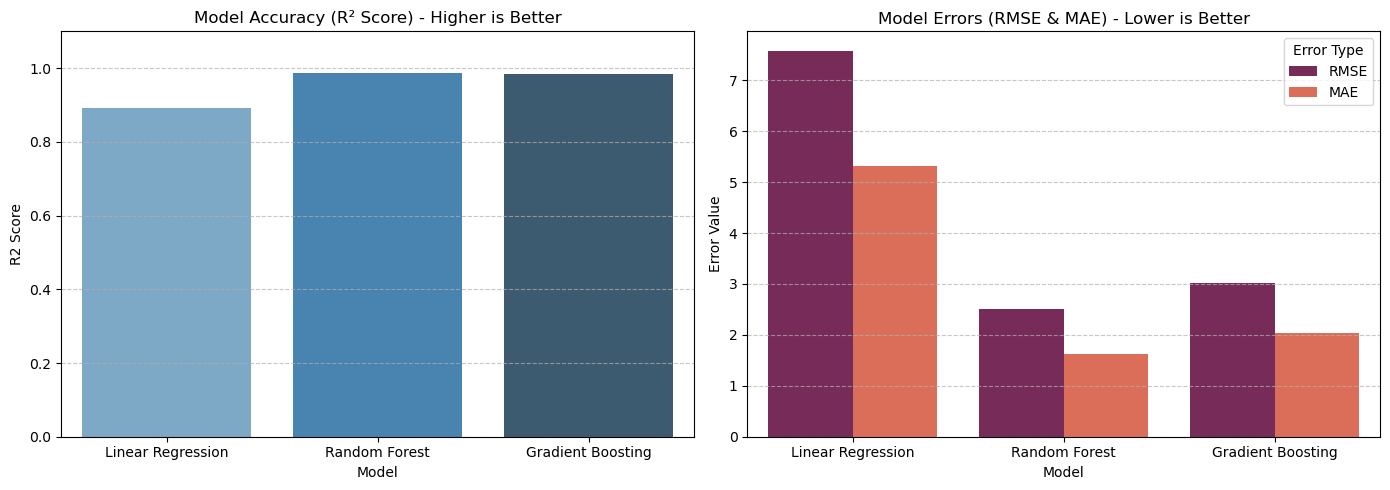

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
# --- Subplot 1: R2 Score Accuracy
sns.barplot(data=results_df, x="Model", y="R2 Score", ax=axes[0], palette="Blues_d")
axes[0].set_title("Model Accuracy (R² Score) - Higher is Better")
axes[0].set_ylim(0, 1.1) 
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Errors MSE and MAE
# We use pd.melt to restructure the dataframe so Seaborn can group the error bars side-by-side
error_df = results_df.melt(id_vars="Model", value_vars=["RMSE", "MAE"], 
                           var_name="Error Type", value_name="Error Value")

sns.barplot(data=error_df, x="Model", y="Error Value", hue="Error Type", ax=axes[1], palette="rocket")
axes[1].set_title("Model Errors (RMSE & MAE) - Lower is Better")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show();